In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import glob
from google.colab import files
from google.colab import drive
drive.mount('/gdrive', force_remount=True)



Mounted at /gdrive


# 음성데이터 세션 나누기

In [9]:
AI_root = glob.glob(r"/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/*")
ori_root = glob.glob(r"/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/원본/*")
X_path = AI_root + ori_root
print(X_path)

['/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.vampire - ROSÉ (ai cover).wav', "/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Taylor Swift IA - we can't be friends (wait for your love) (artificial intelligence version).wav", '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Passenger - LET HER GO (ED SHEERAN - A.I COVER LYRICS).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Jungkook - Off My Face (AI Cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Copy of Standing Next to You - AI theWeeknd.wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Copy of Jungkook - Die For You (AI cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.CHIQUITA Ai Cover “ 2002” (Anne Marie).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Avril Lavigne - August (Taylor Swift Cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Avril Lavigne - 3am (Halsey AI Cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/원본/ori.Taylor Swift – august.wav', '/gdrive/MyDrive/빅데이터 45기_파이널 

In [10]:
pip install pydub

In [11]:
#음원 구간별 추출
'''
from pydub import AudioSegment
import os

for a in X_path:
  # wav 파일 로드
  audio = AudioSegment.from_wav(a)

  # 분할 간격 설정 (밀리초 단위)
  interval = 10 * 1000  # 10초 = 10,000 밀리초
  step = 5 * 1000  # 5초 = 5,000 밀리초

  # 전체 길이
  length = len(audio) #밀리초로 환산됨


  # 저장할 디렉토리 설정
  output_dir = r'/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save'

  # 분할 및 저장
  for i in range(0, length, step):
      start_time = i  # 시작 시간 (밀리초 단위)
      end_time = i + interval  # 종료 시간 (밀리초 단위)
      split_audio = audio[start_time:end_time]
      start_sec = start_time // 1000  # 시작 시간 (초 단위)
      end_sec = end_time // 1000  # 종료 시간 (초 단위)
      filename = os.path.join(output_dir, f"output_{start_sec}-{end_sec}_{os.path.basename(a)}.wav")
      split_audio.export(filename, format="wav")
      print(f"Saved {filename}")

  print("분할 완료")
  '''


Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_0-10_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_5-15_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_10-20_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_15-25_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_20-30_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_25-35_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_30-40_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_35-45_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_40-50_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_45-55_AI.vampire - ROSÉ (

# 모델링 시작

In [13]:
#구간별 추출한 데이터 경로 저장
X_path_new = glob.glob(r"/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/*")
print(len(X_path_new))

800


In [14]:
import ntpath # 특정 경로에서 파일들을 가져오는 라이브러리
y = np.empty((0, 1)) # 비어있는 리스트 만들기

for f in X_path_new:
    if 'ori' in ntpath.basename(f): #  음성 데이터가 있는 디렉토리의 데이터가 '원본' 음성 : 0
        resp = np.array([0])  #   [0]
    elif 'AI' in ntpath.basename(f): # 음성 데이터가 있는 디렉토리의 데이터가 'AI' 음성 : 1
        resp = np.array([1])  # [1]
    resp = resp.reshape(1, 1)
    y = np.vstack((y, resp))
print (y)

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.

In [15]:
# 데이터셋 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_path_new, y, test_size=0.25, random_state=42)
print(len(X_train)) # 600
print(len(X_test)) # 200

600
200


In [ ]:
# 첫 번째 파일의 샘플 레이트 확인
'''
sample_rate = librosa.load(X_train[0],sr = 16000)[1]
print(sample_rate)
'''
file_path = X_train[0]  # Replace with the actual path to your audio file
y, sr = librosa.load(file_path, sr=16000)  # Load the audio file with a sample rate of 16000 Hz


In [16]:
# 음성파일 읽기 & 디지털 변환 함수
def librosa_read_wav_files(wav_files):
    if not isinstance(wav_files, list): # isinstance(1, int) # 1이 int형인지 알아본다. 결과는 True
        wav_files = [wav_files]
    return [librosa.load(f, sr = 16000)[0] for f in wav_files] # 음성파일 읽기

In [17]:
# train/test 음성파일 읽기
X_train2 = librosa_read_wav_files(X_train)
X_test2  = librosa_read_wav_files(X_test)
print(len(X_train2)) # 600
print(len(X_test2)) # 200


600
200


In [6]:
!pip install gammatone librosa numpy scipy


In [25]:
# 오디오 특징 추출 함수 (gfcc)
from gammatone.gtgram import gtgram
from scipy.fftpack import dct

def compute_gfcc(y, sr, n_gfcc=13, n_filters=64, win_length=0.025, hop_length=0.01, f_min=50):
    # Compute Gammatone spectrogram
    gt_spectrogram = gtgram(y, sr, win_length, hop_length, n_filters, f_min)

    # Compute log power spectrogram
    log_gt_spectrogram = np.log(gt_spectrogram + 1e-10)

    # Compute DCT to get GFCC
    gfcc = dct(log_gt_spectrogram, type=2, axis=0, norm='ortho')[:n_gfcc]

    return gfcc.T
'''
wav_data: 입력 오디오 데이터 (1차원 NumPy 배열)
sample_rate: 샘플링 레이트 (Hz)
window_time: 윈도우 길이 (초)
hop_time: 홉 길이 (초)
channels: 필터 수
f_min: 최소 주파수 (Hz)
'''

In [26]:
X_train_gfcc = [compute_gfcc(y, sr=16000) for y in X_train2]
X_test_gfcc = [compute_gfcc(y, sr=16000) for y in X_test2]
print(X_train_gfcc[0].shape)

(998, 13)


In [31]:
print(X_test_gfcc[9].shape)

(871, 13)


In [32]:
# 넘파이 변환 중 길이 안맞아서 패딩 추가함
def pad_sequences(sequences, maxlen=None, dtype='float32', padding='post', value=0.0):
    """
    Pad each sequence to the same length: the length of the longest sequence.
    If maxlen is provided, any sequence longer than maxlen is truncated to maxlen.
    """
    if not hasattr(sequences, '__len__'):
        raise ValueError('`sequences` must be iterable.')

    lengths = [len(s) for s in sequences]

    if maxlen is None:
        maxlen = max(lengths)

    sample_shape = tuple()
    for s in sequences:
        if len(s) > 0:
            sample_shape = np.asarray(s).shape[1:] # # Convert GFCC features to the shape suitable for CNN input
            break

    is_dtype_str = np.issubdtype(dtype, np.str_) or np.issubdtype(dtype, np.unicode_)
    if isinstance(value, (str, bytes)) and not is_dtype_str:
        raise ValueError(f'`dtype` {dtype} is not compatible with `value` of type {type(value).__name__}')

    x = np.full((len(sequences), maxlen) + sample_shape, value, dtype=dtype)
    for idx, s in enumerate(sequences):
        if len(s) == 0:
            continue  # empty list/array was found
        trunc = s[:maxlen]
        trunc = np.asarray(trunc, dtype=dtype)
        x[idx, :len(trunc)] = trunc

    return x

# Pad the sequences
X_train_gfcc_padded = pad_sequences(X_train_gfcc, dtype='float32')
X_test_gfcc_padded = pad_sequences(X_test_gfcc, dtype='float32')

# Add channel dimension
X_train_gfcc_padded = X_train_gfcc_padded[..., np.newaxis]
X_test_gfcc_padded = X_test_gfcc_padded[..., np.newaxis]

print(X_train_gfcc_padded.shape)
print(X_test_gfcc_padded.shape)

'''
(데이터수, gfcc 특징벡터 시간 프레임 수, gfcc 차원 수, 채널수)
'''


(600, 998, 13, 1)
(200, 998, 13, 1)


In [ ]:
'''
# 오디오 특징 추출 함수 (mfcc)
def extract_features(audio_samples, sample_rate):
    extracted_features = np.empty((0, 101)) # (1,41) : 41개의 값을 받을 메모리를 할당하겠다는 뜻
    if not isinstance(audio_samples, list):
        audio_samples = [audio_samples]

    for sample in audio_samples:
        zero_cross_feat = librosa.feature.zero_crossing_rate(sample).mean()
        mfccs = librosa.feature.mfcc(y=sample, sr=sample_rate, n_mfcc=100) # 오디오에서 40개 특징 추출
        mfccsscaled = np.mean(mfccs.T,axis=0)  # 각 주파수별 평균값을 구하기
        mfccsscaled = np.append(mfccsscaled, zero_cross_feat)
        mfccsscaled = mfccsscaled.reshape(1, 101)
        extracted_features = np.vstack((extracted_features, mfccsscaled))
    return extracted_features
    '''

In [ ]:
# 오디오 특징 추출
# wave_rate 에 사람음성에 속하는 주파수 영역을 주어야 한다.
'''
X_train_features = extract_features(X_train2, sample_rate) # wav_rate=22050(sample_rate)
X_test_features  = extract_features(X_test2, sample_rate) # wav_rate=22050(sample_rate)
print(X_train_features.shape) # (600, 101)
print(X_test_features.shape) # (200, 101)
'''

In [34]:
from keras import layers
from keras import models
from keras import optimizers
from keras import losses
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [36]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(998, 13, 1)),  # Input shape: (time_frames, features, channels)
    MaxPooling2D(pool_size=(2, 2)),  # Reduce dimensionality
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),  # Flatten the 2D outputs to 1D
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Adjust the output layer according to the number of classes
])


In [ ]:
# 신경망 구축
'''
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(101,1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(256, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.summary()
'''

In [37]:
# 학습환경
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [38]:
# 여기서는 val_accuracy 모니터링해서 성능이 좋아지지 않으면 조기 종료 하게 함.
# early_stop = EarlyStopping(monitor='val_accuracy', verbose=1, patience=5)

In [39]:
check_point = ModelCheckpoint('best_model.h5', verbose=1,
                              monitor='val_loss', save_best_only=True)

In [42]:
history = model.fit(X_train_gfcc_padded, y_train, epochs=50, batch_size=32, validation_data=(X_test_gfcc_padded,y_test), verbose=1,
          callbacks=[check_point])


Epoch 1/50
19/19 [==============================] - ETA: 0s - loss: 0.0443 - accuracy: 0.9867
Epoch 1: val_loss did not improve from 0.54176
19/19 [==============================] - 1s 37ms/step - loss: 0.0443 - accuracy: 0.9867 - val_loss: 0.8085 - val_accuracy: 0.7100
Epoch 2/50
15/19 [======================>.......] - ETA: 0s - loss: 0.0520 - accuracy: 0.9812
Epoch 2: val_loss did not improve from 0.54176
19/19 [==============================] - 0s 15ms/step - loss: 0.0519 - accuracy: 0.9817 - val_loss: 0.7237 - val_accuracy: 0.7300
Epoch 3/50
16/19 [========================>.....] - ETA: 0s - loss: 0.0374 - accuracy: 0.9941
Epoch 3: val_loss did not improve from 0.54176
19/19 [==============================] - 0s 14ms/step - loss: 0.0355 - accuracy: 0.9950 - val_loss: 0.9668 - val_accuracy: 0.6800
Epoch 4/50
17/19 [=========================>....] - ETA: 0s - loss: 0.0255 - accuracy: 0.9963
Epoch 4: val_loss did not improve from 0.54176
19/19 [==============================] - 0s 14

Text(0, 0.5, 'ACC')

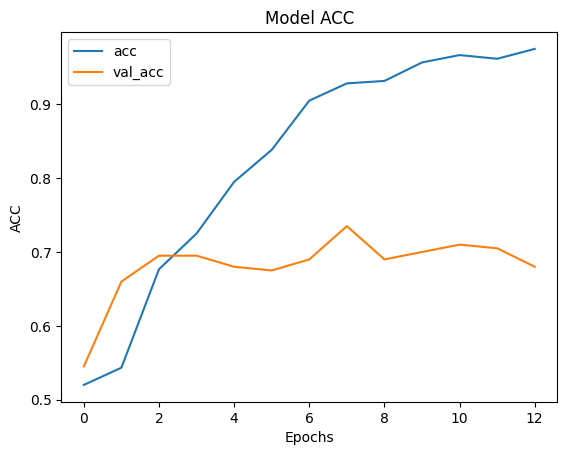

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['acc','val_acc'])
plt.title('Model ACC')
plt.xlabel('Epochs')
plt.ylabel('ACC')